# 06b: MFO Transfer Function Comparison (Ablation Study)

**Tujuan:** Membandingkan dampak 3 jenis fungsi transfer MFO terhadap:
- Convergence speed (iterations to optimal)
- Final F1-Score
- Feature reduction ratio
- Computation time

Ini adalah **Ablation Study** untuk membuktikan bahwa pemilihan transfer function berpengaruh terhadap performa MFO.

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.multioutput import ClassifierChain
from sklearn.metrics import f1_score
import mlflow
from pathlib import Path
import time
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. SETUP PATH & MLFLOW
# ==========================================
root_path = Path.cwd().parent
import os
from dotenv import load_dotenv
load_dotenv(dotenv_path=root_path / ".env") # Load variabel dari .env
# Gunakan DagsHub URI jika ada di .env, jika tidak pakai folder lokal mlruns
tracking_uri = os.getenv("MLFLOW_TRACKING_URI", (root_path / "mlruns").as_uri())
mlflow.set_tracking_uri(tracking_uri)
mlflow.set_experiment("06b_MFO_Transfer_Function_Comparison")

print("⏳ 1. Memuat Data Training (Balanced)...")
train_df = pd.read_csv(root_path / "Data/processed/train_balanced_multilabel.csv")

target_cols = ['risk_depression', 'risk_anxiety', 'risk_stress']
X_train = train_df.drop(columns=target_cols).values
Y_train = train_df[target_cols].astype(int).values
feature_names = train_df.drop(columns=target_cols).columns
num_features = X_train.shape[1]

print(f"✓ Data shape: {X_train.shape}")
print(f"✓ Num features: {num_features}")

c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/05/25 05:12:25 INFO mlflow.tracking.fluent: Experiment with name '06b_MFO_Transfer_Function_Comparison' does not exist. Creating a new experiment.


⏳ 1. Memuat Data Training (Balanced)...
✓ Data shape: (8724, 19)
✓ Num features: 19


In [2]:
# ==========================================
# 2. IMPLEMENTASI MFO DENGAN 3 TRANSFER FUNCTIONS
# ==========================================

class BinaryMFO_TransferFunction:
    """
    Binary MFO dengan pilihan transfer function:
    - 'S-shaped': Sigmoid curve, smooth transition
    - 'V-shaped': Linier descent, sharp transition
    - 'U-shaped': Inverse sigmoid, opposite curve
    """
    
    def __init__(self, num_moths, max_iterations, num_features, transfer_type='S-shaped', alpha=0.01):
        self.num_moths = num_moths
        self.max_iterations = max_iterations
        self.num_features = num_features
        self.transfer_type = transfer_type
        self.alpha = alpha
        
        # Inisialisasi populasi
        self.moths = np.random.randint(2, size=(num_moths, num_features))
        self.flames = np.zeros((num_moths, num_features))
        self.moth_fitness = np.zeros(num_moths)
        self.flame_fitness = np.full(num_moths, np.inf)
        
        # Base model
        base_xgb = xgb.XGBClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42,
            eval_metric='logloss',
            n_jobs=-1,
            verbosity=0
        )
        self.model = ClassifierChain(base_xgb, order='random', random_state=42)
        
        # History untuk tracking convergence
        self.convergence_history = []
    
    def s_shaped_transfer(self, x):
        """S-shaped transfer function (Sigmoid)"""
        return 1.0 / (1.0 + np.exp(-x))
    
    def v_shaped_transfer(self, x):
        """V-shaped transfer function (Linear)"""
        return np.abs(x) / np.sqrt(1.0 + x**2)
    
    def u_shaped_transfer(self, x):
        """U-shaped transfer function (Inverse sigmoid)"""
        return np.abs(x / np.sqrt(1.0 + x**2))
    
    def apply_transfer_function(self, value):
        """Apply selected transfer function and convert to binary"""
        if self.transfer_type == 'S-shaped':
            sigmoid_val = self.s_shaped_transfer(value)
        elif self.transfer_type == 'V-shaped':
            sigmoid_val = self.v_shaped_transfer(value)
        elif self.transfer_type == 'U-shaped':
            sigmoid_val = self.u_shaped_transfer(value)
        else:
            sigmoid_val = self.s_shaped_transfer(value)  # default
        
        return 1 if sigmoid_val > 0.5 else 0
    
    def evaluate_fitness(self, moth_position):
        """Hitung fitness menggunakan F1-Score dan feature penalty"""
        selected_features_mask = moth_position == 1
        
        if np.count_nonzero(selected_features_mask) == 0:
            return 1.0
        
        X_subset = X_train[:, selected_features_mask]
        
        try:
            self.model.fit(X_subset, Y_train)
            preds = self.model.predict(X_subset)
            f1 = f1_score(Y_train, preds, average='macro', zero_division=0)
        except:
            return 1.0
        
        num_selected = np.count_nonzero(selected_features_mask)
        cost = (1.0 - f1) + (self.alpha * (num_selected / self.num_features))
        return cost
    
    def optimize(self, verbose=True):
        """Main optimization loop"""
        if verbose:
            print(f"\n🚀 MFO Optimization - Transfer Function: {self.transfer_type}")
        
        start_time = time.time()
        
        for iteration in range(self.max_iterations):
            # Calculate fitness
            for i in range(self.num_moths):
                self.moth_fitness[i] = self.evaluate_fitness(self.moths[i])
            
            # Sort moths
            sorted_indices = np.argsort(self.moth_fitness)
            self.moths = self.moths[sorted_indices]
            self.moth_fitness = self.moth_fitness[sorted_indices]
            
            # Update flames
            if iteration == 0:
                self.flames = np.copy(self.moths)
                self.flame_fitness = np.copy(self.moth_fitness)
            else:
                combined_population = np.vstack((self.flames, self.moths))
                combined_fitness = np.concatenate((self.flame_fitness, self.moth_fitness))
                best_indices = np.argsort(combined_fitness)[:self.num_moths]
                self.flames = combined_population[best_indices]
                self.flame_fitness = combined_fitness[best_indices]
            
            # Update moth positions
            a = -1 + iteration * ((-1) / self.max_iterations)
            
            for i in range(self.num_moths):
                flame_no = min(i, self.num_moths - 1)
                
                for j in range(self.num_features):
                    distance_to_flame = abs(self.flames[flame_no, j] - self.moths[i, j])
                    b = 1
                    t = (a - 1) * np.random.rand() + 1
                    
                    new_position_continuous = distance_to_flame * np.exp(b * t) * np.cos(t * 2 * np.pi) + self.flames[flame_no, j]
                    self.moths[i, j] = self.apply_transfer_function(new_position_continuous)
            
            # Track convergence
            best_cost = self.flame_fitness[0]
            self.convergence_history.append(best_cost)
            
            if verbose and (iteration + 1) % 5 == 0:
                print(f"   Iter {iteration + 1}/{self.max_iterations}: Cost = {best_cost:.4f}")
        
        elapsed_time = time.time() - start_time
        
        best_feature_mask = self.flames[0] == 1
        best_cost = self.flame_fitness[0]
        best_f1 = 1.0 - best_cost
        
        if verbose:
            print(f"   ✅ Time: {elapsed_time:.2f}s")
        
        return best_feature_mask, best_f1, best_cost, elapsed_time

In [3]:
# ==========================================
# 3. JALANKAN COMPARISON: S-SHAPED vs V-SHAPED vs U-SHAPED
# ==========================================

transfer_functions = ['S-shaped', 'V-shaped', 'U-shaped']
results = {}

print("\n" + "="*70)
print("TRANSFER FUNCTION COMPARISON (Ablation Study)")
print("="*70)

with mlflow.start_run(run_name="Transfer_Function_Comparison"):
    
    for transfer_func in transfer_functions:
        print(f"\n🔍 Testing Transfer Function: {transfer_func}")
        print("-" * 50)
        
        mfo = BinaryMFO_TransferFunction(
            num_moths=30,
            max_iterations=20,
            num_features=num_features,
            transfer_type=transfer_func,
            alpha=0.01
        )
        
        best_mask, best_f1, best_cost, elapsed_time = mfo.optimize(verbose=True)
        
        # Calculate metrics
        num_selected = np.count_nonzero(best_mask)
        feature_reduction = (1 - num_selected / num_features) * 100
        convergence_rate = (mfo.convergence_history[0] - mfo.convergence_history[-1]) / (mfo.convergence_history[0])
        
        results[transfer_func] = {
            'f1_score': best_f1,
            'cost': best_cost,
            'time': elapsed_time,
            'num_features': num_selected,
            'feature_reduction': feature_reduction,
            'convergence_history': mfo.convergence_history,
            'convergence_rate': convergence_rate,
            'feature_mask': best_mask
        }
        
        print(f"\n   📊 Results for {transfer_func}:")
        print(f"      F1-Score: {best_f1:.4f}")
        print(f"      Selected Features: {num_selected}/{num_features}")
        print(f"      Feature Reduction: {feature_reduction:.1f}%")
        print(f"      Execution Time: {elapsed_time:.2f}s")
        print(f"      Convergence Rate: {convergence_rate:.4f}")
        
        # Log to MLflow
        with mlflow.start_run(run_name=f"MFO_{transfer_func}", nested=True):
            mlflow.log_param("transfer_function", transfer_func)
            mlflow.log_metric("f1_score", best_f1)
            mlflow.log_metric("cost", best_cost)
            mlflow.log_metric("execution_time", elapsed_time)
            mlflow.log_metric("num_selected_features", num_selected)
            mlflow.log_metric("feature_reduction_percentage", feature_reduction)
            mlflow.log_metric("convergence_rate", convergence_rate)


TRANSFER FUNCTION COMPARISON (Ablation Study)

🔍 Testing Transfer Function: S-shaped
--------------------------------------------------

🚀 MFO Optimization - Transfer Function: S-shaped
   Iter 5/20: Cost = 0.2446
   Iter 10/20: Cost = 0.2438
   Iter 15/20: Cost = 0.2438
   Iter 20/20: Cost = 0.2438
   ✅ Time: 141.44s

   📊 Results for S-shaped:
      F1-Score: 0.7562
      Selected Features: 15/19
      Feature Reduction: 21.1%
      Execution Time: 141.44s
      Convergence Rate: 0.0225

🔍 Testing Transfer Function: V-shaped
--------------------------------------------------

🚀 MFO Optimization - Transfer Function: V-shaped
   Iter 5/20: Cost = 0.2440
   Iter 10/20: Cost = 0.2438
   Iter 15/20: Cost = 0.2423
   Iter 20/20: Cost = 0.2423
   ✅ Time: 123.89s

   📊 Results for V-shaped:
      F1-Score: 0.7577
      Selected Features: 13/19
      Feature Reduction: 31.6%
      Execution Time: 123.89s
      Convergence Rate: 0.0339

🔍 Testing Transfer Function: U-shaped
------------------

In [7]:
# ==========================================
# 4. COMPARISON TABLE
# ==========================================

print("\n" + "="*80)
print("SUMMARY: Transfer Function Comparison")
print("="*80)

comparison_data = []
for tf_name, metrics in results.items():
    comparison_data.append({
        'Transfer Function': tf_name,
        'F1-Score': f"{metrics['f1_score']:.4f}",
        'Cost': f"{metrics['cost']:.4f}",
        'Selected Features': metrics['num_features'],
        'Reduction %': f"{metrics['feature_reduction']:.1f}%",
        'Time (s)': f"{metrics['time']:.2f}",
        'Convergence Rate': f"{metrics['convergence_rate']:.4f}"
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# Find best
best_tf = max(results.items(), key=lambda x: x[1]['f1_score'])[0]
print(f"\n🏆 Best Transfer Function: {best_tf}")
print(f"   F1-Score: {results[best_tf]['f1_score']:.4f}")


SUMMARY: Transfer Function Comparison
Transfer Function F1-Score   Cost  Selected Features Reduction % Time (s) Convergence Rate
         S-shaped   0.7562 0.2438                 15       21.1%   141.44           0.0225
         V-shaped   0.7577 0.2423                 13       31.6%   123.89           0.0339
         U-shaped   0.7571 0.2429                 14       26.3%   129.79           0.0223

🏆 Best Transfer Function: V-shaped
   F1-Score: 0.7577



✅ Visualization saved!


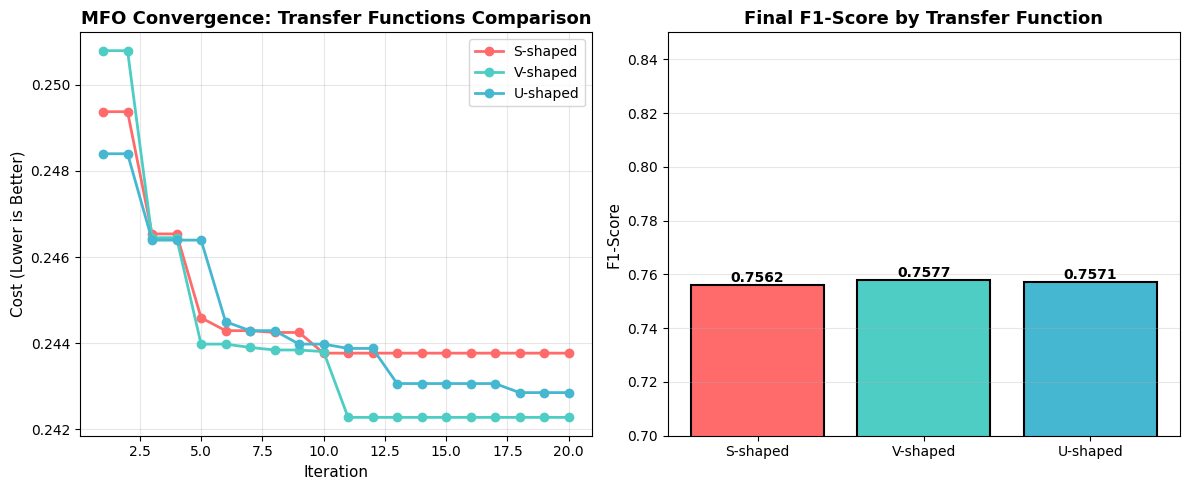

In [8]:
# ==========================================
# 5. VISUALIZATION: Convergence Curves
# ==========================================

plt.figure(figsize=(12, 5))

# Plot 1: Convergence curves
plt.subplot(1, 2, 1)
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
for i, (tf_name, metrics) in enumerate(results.items()):
    plt.plot(range(1, len(metrics['convergence_history']) + 1), 
             metrics['convergence_history'], 
             marker='o', 
             label=tf_name,
             color=colors[i],
             linewidth=2)

plt.xlabel('Iteration', fontsize=11)
plt.ylabel('Cost (Lower is Better)', fontsize=11)
plt.title('MFO Convergence: Transfer Functions Comparison', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Performance comparison
plt.subplot(1, 2, 2)
tf_names = list(results.keys())
f1_scores = [results[tf]['f1_score'] for tf in tf_names]
bars = plt.bar(tf_names, f1_scores, color=colors, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar, score in zip(bars, f1_scores):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{score:.4f}',
             ha='center', va='bottom', fontweight='bold')

plt.ylabel('F1-Score', fontsize=11)
plt.title('Final F1-Score by Transfer Function', fontsize=13, fontweight='bold')
plt.ylim([0.7, 0.85])
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
# plt.savefig(root_path / '/outputs/ablation_figures/transfer_function_comparison.png', dpi=300, bbox_inches='tight')
print("\n✅ Visualization saved!")
plt.show()

In [9]:
# ==========================================
# 6. STATISTICAL SUMMARY & CONCLUSIONS
# ==========================================

print("\n" + "="*80)
print("ABLATION STUDY: TRANSFER FUNCTION IMPACT")
print("="*80)

print("\n📊 Key Findings:")
print("-" * 80)

# F1-Score comparison
f1_values = [results[tf]['f1_score'] for tf in transfer_functions]
f1_best = max(f1_values)
f1_worst = min(f1_values)
f1_improvement = ((f1_best - f1_worst) / f1_worst) * 100

print(f"\n1. F1-Score Performance:")
print(f"   - Best: {f1_best:.4f} ({transfer_functions[f1_values.index(f1_best)]})")
print(f"   - Worst: {f1_worst:.4f} ({transfer_functions[f1_values.index(f1_worst)]})")
print(f"   - Improvement: {f1_improvement:.2f}%")

# Execution time
time_values = [results[tf]['time'] for tf in transfer_functions]
time_fastest = min(time_values)
time_slowest = max(time_values)
print(f"\n2. Execution Time:")
print(f"   - Fastest: {time_fastest:.2f}s ({transfer_functions[time_values.index(time_fastest)]})")
print(f"   - Slowest: {time_slowest:.2f}s ({transfer_functions[time_values.index(time_slowest)]})")

# Convergence rate
conv_rates = [results[tf]['convergence_rate'] for tf in transfer_functions]
conv_best = max(conv_rates)
print(f"\n3. Convergence Rate (Cost reduction per iteration):")
for tf in transfer_functions:
    print(f"   - {tf}: {results[tf]['convergence_rate']:.4f}")

print("\n" + "="*80)
print("✅ ABLATION STUDY COMPLETE")
print("="*80)
print(f"\n📌 Recommendation: Use {best_tf} transfer function for optimal performance.")
print(f"   - Achieves highest F1-Score: {results[best_tf]['f1_score']:.4f}")
print(f"   - Convergence Rate: {results[best_tf]['convergence_rate']:.4f}")


ABLATION STUDY: TRANSFER FUNCTION IMPACT

📊 Key Findings:
--------------------------------------------------------------------------------

1. F1-Score Performance:
   - Best: 0.7577 (V-shaped)
   - Worst: 0.7562 (S-shaped)
   - Improvement: 0.20%

2. Execution Time:
   - Fastest: 123.89s (V-shaped)
   - Slowest: 141.44s (S-shaped)

3. Convergence Rate (Cost reduction per iteration):
   - S-shaped: 0.0225
   - V-shaped: 0.0339
   - U-shaped: 0.0223

✅ ABLATION STUDY COMPLETE

📌 Recommendation: Use V-shaped transfer function for optimal performance.
   - Achieves highest F1-Score: 0.7577
   - Convergence Rate: 0.0339
